Tren Konsumsi Pangan Pokok Nasional (2021–2025)
Dataset : Rata-rata Konsumsi per Jenis Pangan Penduduk Indonesia Kabupaten Kota Tahun 2025 (Badan Pangan Indoensia)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv(r"D:\12345678 porto\1778632956.csv")

df.head()

,No,Tahun,Kode_Wilayah,Provinsi,Kabupaten_Kota,Kelompok_Bahan_Pangan,Komoditas,Konsumsi_Pangan
0,1,2025.0,3101.0,DKI Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Padi-Padian,102
1,2,2025.0,3101.0,DKI Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Beras,88.6
2,3,2025.0,3101.0,DKI Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Jagung,0.2
3,4,2025.0,3101.0,DKI Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Terigu,13.1
4,5,2025.0,3101.0,DKI Jakarta,Administrasi Kepulauan Seribu,Umbi-umbian,Umbi-umbian,9.3


EDA

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87380 entries, 0 to 87379
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   No                     87380 non-null  object 
 1   Tahun                  87363 non-null  float64
 2   Kode_Wilayah           87363 non-null  float64
 3   Provinsi               87363 non-null  object 
 4   Kabupaten_Kota         87363 non-null  object 
 5   Kelompok_Bahan_Pangan  87363 non-null  object 
 6   Komoditas              87363 non-null  object 
 7   Konsumsi_Pangan        87362 non-null  object 
dtypes: float64(2), object(6)
memory usage: 5.3+ MB


In [17]:
df.isnull().sum()

,0
No,0
Tahun,17
Kode_Wilayah,17
Provinsi,17
Kabupaten_Kota,17
Kelompok_Bahan_Pangan,17
Komoditas,17
Konsumsi_Pangan,18


EDA Multivariat

In [24]:
df_2025 = df[df["Tahun"] == 2025]

komoditas_pilihan = ["Beras", "Jagung", "Terigu", "Singkong", "Kentang"]
df_pilihan = df_2025[df_2025["Komoditas"].isin(komoditas_pilihan)].copy()

df_pilihan["Konsumsi_Pangan"] = pd.to_numeric(
    df_pilihan["Konsumsi_Pangan"], errors="coerce"
)

df_pilihan["Konsumsi_Pangan"] = df_pilihan["Konsumsi_Pangan"].fillna(0)

matrix_pangan = df_pilihan.pivot_table(
    index="Provinsi", columns="Komoditas", values="Konsumsi_Pangan", aggfunc="mean"
)

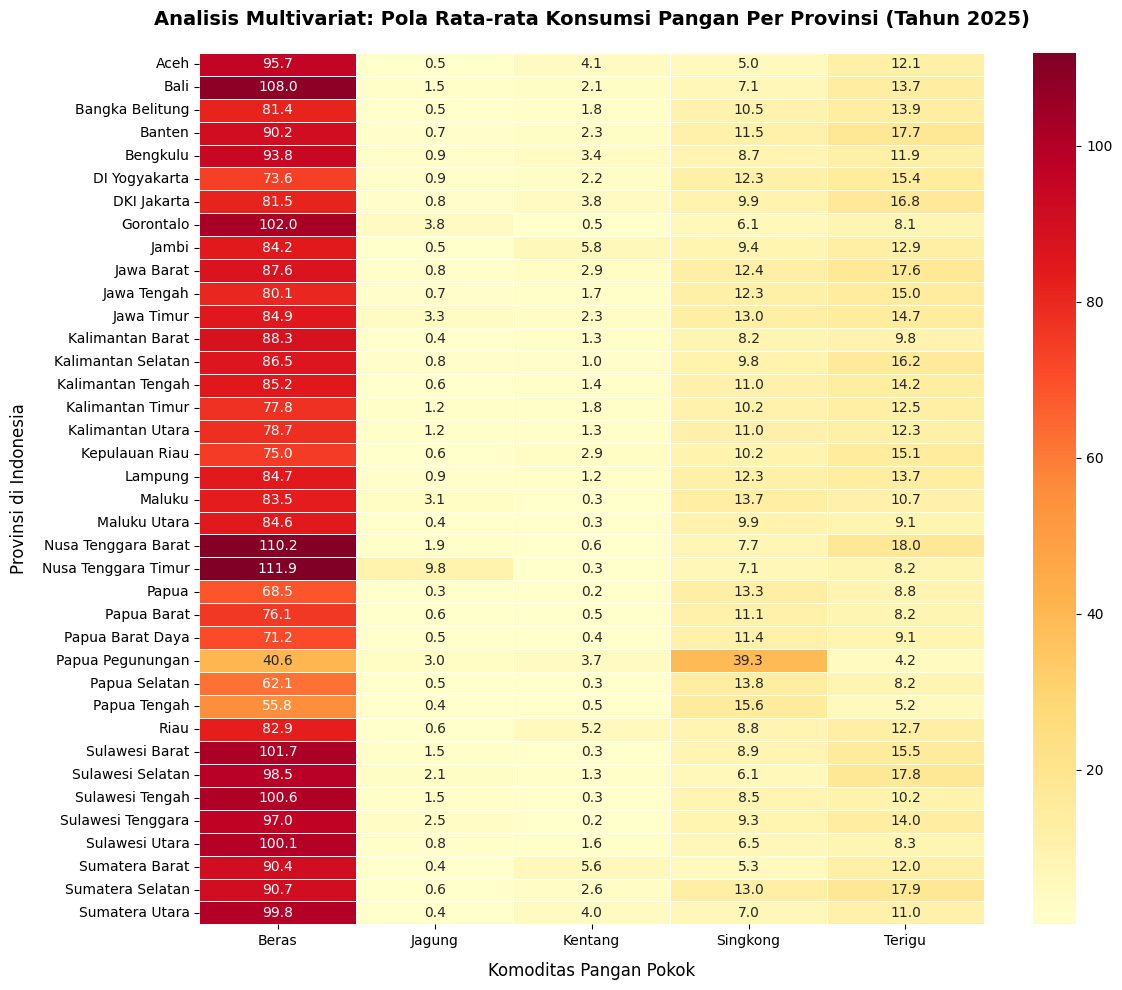

In [25]:
plt.figure(figsize=(12, 10))

sns.heatmap(matrix_pangan, annot=True, cmap="YlOrRd", fmt=".1f", linewidths=0.5)

plt.title(
    "Analisis Multivariat: Pola Rata-rata Konsumsi Pangan Per Provinsi (Tahun 2025)",
    fontsize=14,
    pad=20,
    weight="bold",
)
plt.xlabel("Komoditas Pangan Pokok", fontsize=12, labelpad=10)
plt.ylabel("Provinsi di Indonesia", fontsize=12, labelpad=10)

plt.tight_layout()

plt.show()

In [34]:
df = df.drop(columns=["No"], errors="ignore")

df.head()

,Tahun,Kode_Wilayah,Provinsi,Kabupaten_Kota,Kelompok_Bahan_Pangan,Komoditas,Konsumsi_Pangan
0,2025.0,3101.0,DKI Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Padi-Padian,102
1,2025.0,3101.0,DKI Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Beras,88.6
2,2025.0,3101.0,DKI Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Jagung,0.2
3,2025.0,3101.0,DKI Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Terigu,13.1
4,2025.0,3101.0,DKI Jakarta,Administrasi Kepulauan Seribu,Umbi-umbian,Umbi-umbian,9.3


In [37]:
df["Provinsi"] = df["Provinsi"].astype(str).str.strip().str.title()
df["Kabupaten_Kota"] = (
    df["Kabupaten_Kota"].astype(str).str.strip().str.title()
)
df["Komoditas"] = df["Komoditas"].astype(str).str.strip().str.title()

df["Komoditas"] = df["Komoditas"].replace("Teriku", "Terigu")

df.head()

,Tahun,Kode_Wilayah,Provinsi,Kabupaten_Kota,Kelompok_Bahan_Pangan,Komoditas,Konsumsi_Pangan
0,2025.0,3101.0,Dki Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Padi-Padian,102
1,2025.0,3101.0,Dki Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Beras,88.6
2,2025.0,3101.0,Dki Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Jagung,0.2
3,2025.0,3101.0,Dki Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Terigu,13.1
4,2025.0,3101.0,Dki Jakarta,Administrasi Kepulauan Seribu,Umbi-umbian,Umbi-Umbian,9.3


In [38]:
df["Konsumsi_Pangan"] = pd.to_numeric(df["Konsumsi_Pangan"], errors="coerce")

df["Konsumsi_Pangan"] = df["Konsumsi_Pangan"].fillna(0)

df = df.dropna(subset=["Tahun", "Kode_Wilayah"])
df["Tahun"] = df["Tahun"].astype(int)
df["Kode_Wilayah"] = df["Kode_Wilayah"].astype(int)

df.head()

,Tahun,Kode_Wilayah,Provinsi,Kabupaten_Kota,Kelompok_Bahan_Pangan,Komoditas,Konsumsi_Pangan
0,2025,3101,Dki Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Padi-Padian,102.0
1,2025,3101,Dki Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Beras,88.6
2,2025,3101,Dki Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Jagung,0.2
3,2025,3101,Dki Jakarta,Administrasi Kepulauan Seribu,Padi-Padian,Terigu,13.1
4,2025,3101,Dki Jakarta,Administrasi Kepulauan Seribu,Umbi-umbian,Umbi-Umbian,9.3


([<matplotlib.axis.XTick at 0x7f7d3f5fea80>,
 [Text(2021, 0, '2021'),
  Text(2022, 0, '2022'),
  Text(2023, 0, '2023'),
  Text(2024, 0, '2024'),
  Text(2025, 0, '2025')])

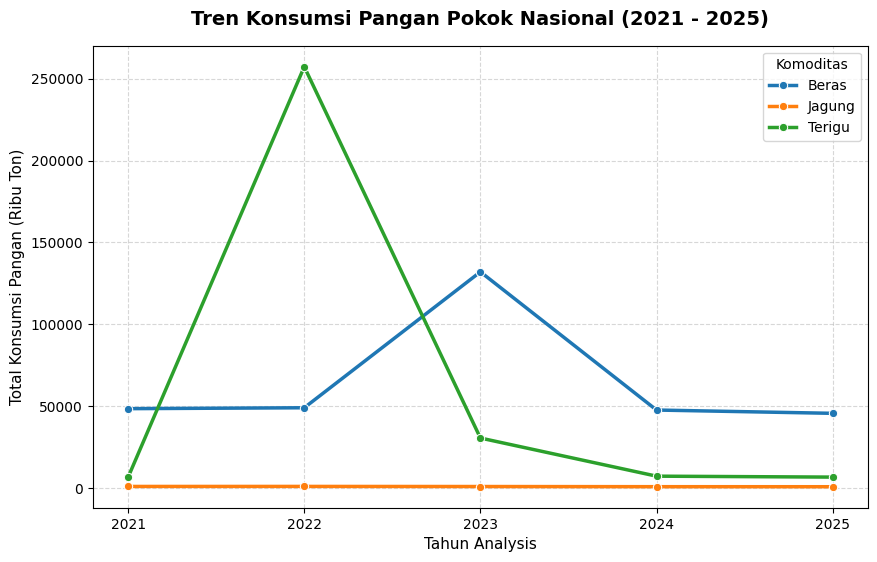

In [41]:
df_tren = df[df["Komoditas"].isin(["Beras", "Terigu", "Jagung"])].copy()
tren_pangan = (
    df_tren.groupby(["Tahun", "Komoditas"])["Konsumsi_Pangan"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=tren_pangan,
    x="Tahun",
    y="Konsumsi_Pangan",
    hue="Komoditas",
    marker="o",
    linewidth=2.5,
)

plt.title(
    "Tren Konsumsi Pangan Pokok Nasional (2021 - 2025)",
    fontsize=14,
    weight="bold",
    pad=15,
)
plt.xlabel("Tahun Analysis", fontsize=11)
plt.ylabel("Total Konsumsi Pangan (Ribu Ton)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(tren_pangan["Tahun"].unique())

In [42]:
plt.tight_layout()
plt.savefig("tren_konsumsi_nasional.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

#INSIGHT

1. beras merupakan komoditi dengan konsumsi paling stabil di tahun 2021 dan 2025, namun mengalami lonjakan kenaikan ditahun 2022-2024. Dimana hal ini sesuai dengan kebutuhan pokok masyarakat indonesia yang menjadikan beras sebagai karbohidrat utama

2. Terigu mengalami kenaikan dari tahun 2021-2023 yang menunjukan adanya pergerakan pola masyarakat yang menyukai produk berbahan dasar tepung.

3. Jagung sangat stabil dari tahun 2021-2025 dimana hal ini menunjukan bahwa masyarakat saat ini tidak menjadikan jagung sebagai sumber karbohidrat utama setiap harinya

#REKOMENDASI


1. penurunan konsumsi beras harus di antisipasi oleh instansi terkait agar tidak terjadinya kelebihan stok pada gudang nasional, yang dapat menyebabkan penurunan harga pada tingkat petani.

2. Bagi pelaku usaha, kenaikan terigu ini dapat di manfaatkan untuk menghasilkan produk berkualitas dari terigu seperti mie, roti, kue, gorengan, kerupuk sehingga meningkatkan nilai rantai pasar ekonomi dan membantu para pelaku usaha/umkm.